# Base

In [1]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
from tqdm import tqdm
import h5py
import hdf5plugin
import os
from dataclasses import astuple, asdict
from global_variables import *

# Save Ground Truths

In [2]:
from deep_bf.config_registery import ConfigRegisteryCenter, BeamformerConfig, ResamplerConfig, ApodConfig
from deep_bf.config_registery.path_center import PathCenter

with ConfigRegisteryCenter() as cc:
    wdbC = cc.get_webdataset_beamformer_packing(id=5)


with PathCenter(location="local") as pc:
    dataset_paths = pc.dataset_paths

bC = BeamformerConfig(23, "DAS", 23, {})

rC = ResamplerConfig(
    23,
    "GridSample",
    {"align_corners": False, "mode": "bilinear", "padding_mode": "border"}
)
aC = ApodConfig(
    23,
    "None",
    {}
)

bfs = [bC]
resamplers = [rC]
apods = [aC]

In [ ]:
import pandas as pd
from deep_bf.webdataset.utils.transform_data import get_transormed_pw
from deep_bf.wrapper.bench.fast_bench import FastBench
from deep_bf.webdataset.utils.ground_truth import save_hdf5_ground_truth
from scipy.signal import hilbert

location = "local"
batch_size = 4

df = pd.read_csv("/home/panda/code/usm/deep_bf/deep_bf/data_handler/data/data.csv")
query = wdbC.samples_organization_config.query
df = df.query(query)
names = df["name"]

nz = wdbC.data_size_config.nz
nx = wdbC.data_size_config.nx
mode = wdbC.data_type_config.type
transform = wdbC.transform_data_config.type

for name in tqdm(names):
    pw = get_transormed_pw(name, wdbC, mode="full", location=location)
    fb = FastBench(pw, nz, nx, bfs, resamplers, apods, meshgrid_nyquist=False, mode=mode, batch_size=batch_size)
    o = fb()

    for beamformer, v1 in o.items():
        for apod, v2 in v1.items():
            for resampler, reconstruction in v2.items():
                r_mean = reconstruction.data.mean(axis=0)

                if mode == "RF":
                    envelope = np.abs(hilbert(r_mean, axis=0))
                else:
                    envelope = np.linalg.norm(r_mean, axis=-1)  # sqrt(I^2 + Q^2)

                save_hdf5_ground_truth(envelope, reconstruction.times, name, mode, transform, nz, nx, beamformer, location=location)

100%|██████████| 544/544 [09:21<00:00,  1.03s/it]


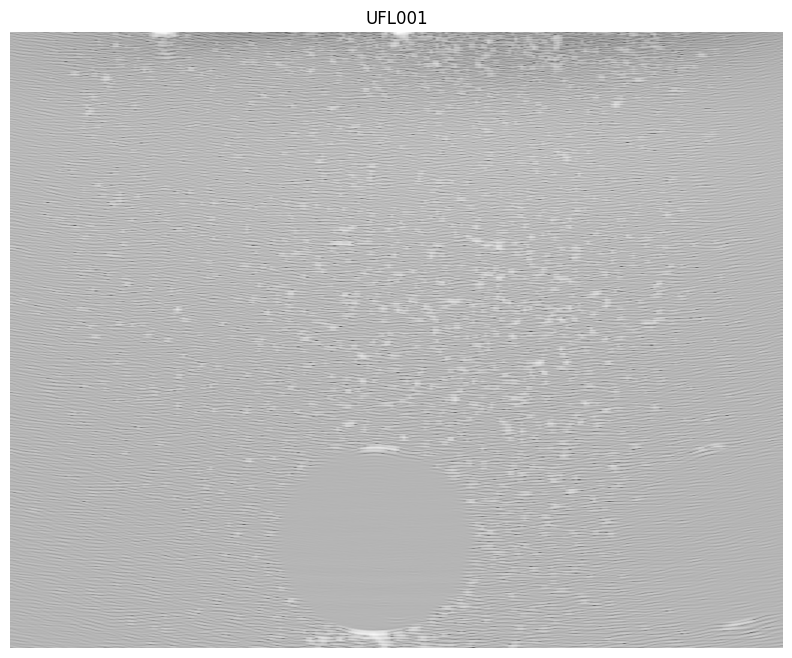

In [ ]:
import matplotlib.pyplot as plt
from deep_bf.webdataset.utils.ground_truth import get_hdf5_ground_truth

with PathCenter(location=location) as pc:
    raw_path = str(pc.dataset_paths.raw)
    dl = DataLoader(raw_path)

name = "UFL001"

pw = dl.get_defined_pwdata(name, mode)
zlims = pw.zlims
xlims = pw.xlims

envelope, _ = get_hdf5_ground_truth(name, mode, transform, nz, nx, beamformer, location=location)
print(np,max(envelope), np.min(envelope))

vmin = -60
vmax = 0

fig, ax = plt.subplots(1, 1, figsize=(10, 8), frameon=False) # figsize ajustado para un solo gráfico

b_mode = 20 * np.log10(envelope + 1e-10)
b_mode -= np.amax(b_mode)
b_mode = np.clip(b_mode, vmin, vmax)

extent = (xlims[0], xlims[-1], zlims[-1], zlims[0])
ax.imshow(b_mode, cmap="gray", vmin=vmin, vmax=vmax, extent=extent, aspect="equal")
ax.set_title(name)
ax.set_axis_off()

plt.show()



# Create WebdatasetBeamformer

In [1]:
from deep_bf.config_registery import ConfigRegisteryCenter, PathCenter

with ConfigRegisteryCenter() as cc:
    wdbC = cc.get_webdataset_beamformer_packing(id=5)

print(wdbC)

WebDatasetBeamformerPacking(webdataset_beamformer_config=WebDatasetBeamformerConfig(id=5, gt_source='DAS', data_type_id=2, data_size_id=2, samples_organization_id=1, transform_data_id=1, resize_gt_id=0), data_type_config=DataTypeConfig(id=2, type='IQ', params={}), data_size_config=DataSizeConfig(id=2, nz=1024, nx=256, ns=2300), samples_organization_config=SamplesOrganizationConfig(id=1, seed=42, ratio=0.9, order='CWH', select_mode='random_split', n_train=-1, n_val=-1, query="(RF == 1) and (nc == 128) and (name.str.slice(0, 3) != 'JHU') and (source == 'CUBDL')", train_idxs='-1', val_idxs='-1'), transform_data_config=TransformDataConfig(id=1, type='sharifzadeh', params={'eps': 1e-08}), resize_gt_config=ResizeGtConfig(id=0, type='original', params={}))


In [2]:
from deep_bf.webdataset.gsi.gsi_for_training import GlobalSamplesIdxForTraining

gsi = GlobalSamplesIdxForTraining(wdbC, 10, "local", reset=True)

Computing samples_idx
Computing samples_idx done


In [6]:
from deep_bf.webdataset.create import create_webdataset_beamformer

location = "local"
create_webdataset_beamformer(wdbC, location=location)

# writing /home/panda/rf_data/dataset/webdataset_beamformer/train/dataset-000.tar 0 0.0 GB 0
# writing /home/panda/rf_data/dataset/webdataset_beamformer/train/dataset-001.tar 100 0.3 GB 100
# writing /home/panda/rf_data/dataset/webdataset_beamformer/train/dataset-002.tar 100 0.3 GB 200
# writing /home/panda/rf_data/dataset/webdataset_beamformer/train/dataset-003.tar 100 0.3 GB 300
# writing /home/panda/rf_data/dataset/webdataset_beamformer/train/dataset-004.tar 100 0.3 GB 400
# writing /home/panda/rf_data/dataset/webdataset_beamformer/val/dataset-000.tar 0 0.0 GB 0


In [1]:
from deep_bf.config_registery import ConfigRegisteryCenter, PathCenter

with ConfigRegisteryCenter() as cc:
    hC = cc.get_hyperparameters_config(id=0)

from deep_bf.webdataset.loader import get_datasets

train, val = get_datasets(hC, 1, False, location="local")

In [ ]:
it = iter(train)
data, sii, angle, gt, key = next(it)

print(data.shape)
print(gt.shape)
print(sii)
print(angle)
print(key)

torch.Size([2, 1, 128, 2300, 2])
torch.Size([2, 2048, 256])
tensor([0, 0])
tensor([15, 15])
['TSH034', 'TSH170']
